In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')
print("Imports done")

Imports done


In [2]:
import os
base = r'C:\Users\chant\ecommerce-analytics\data\raw'

customers  = pd.read_csv(os.path.join(base, 'customers.csv'))
products   = pd.read_csv(os.path.join(base, 'products.csv'))
orders     = pd.read_csv(os.path.join(base, 'orders.csv'), parse_dates=['order_date'])
returns    = pd.read_csv(os.path.join(base, 'returns.csv'))
deliveries = pd.read_csv(os.path.join(base, 'deliveries.csv'))
inventory  = pd.read_csv(os.path.join(base, 'inventory.csv'), parse_dates=['snapshot_date'])

print("customers :", customers.shape)
print("products  :", products.shape)
print("orders    :", orders.shape)
print("returns   :", returns.shape)
print("deliveries:", deliveries.shape)
print("inventory :", inventory.shape)

customers : (5000, 7)
products  : (500, 11)
orders    : (10000, 12)
returns   : (900, 5)
deliveries: (10000, 8)
inventory : (3650, 4)


In [3]:
for name, df in [('customers',customers),('products',products),
                  ('orders',orders),('returns',returns),
                  ('deliveries',deliveries),('inventory',inventory)]:
    print(f"\n{'='*40}")
    print(f" {name.upper()}")
    print(f"{'='*40}")
    print(df.dtypes)
    print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum()>0]}")
    print(f"\nSample:\n{df.head(3)}")


 CUSTOMERS
customer_id       object
name              object
city              object
pincode            int64
household_size     int64
profession        object
is_rural            bool
dtype: object

Missing values:
Series([], dtype: int64)

Sample:
  customer_id          name        city  pincode  household_size profession  \
0      C00000   Karan Vohra   Kozhikode   110002               7   salaried   
1      C00001      Dev Gala   Karaikudi   600001               6   business   
2      C00002  Aayush Loyal  Vijayawada   560001               4   salaried   

   is_rural  
0     False  
1     False  
2      True  

 PRODUCTS
product_id             object
name                   object
category               object
price                 float64
is_perishable            bool
box_size_used          object
actual_size_needed     object
stock_level             int64
reorder_point           int64
seller_id              object
is_authentic             bool
dtype: object

Missing values:
Ser

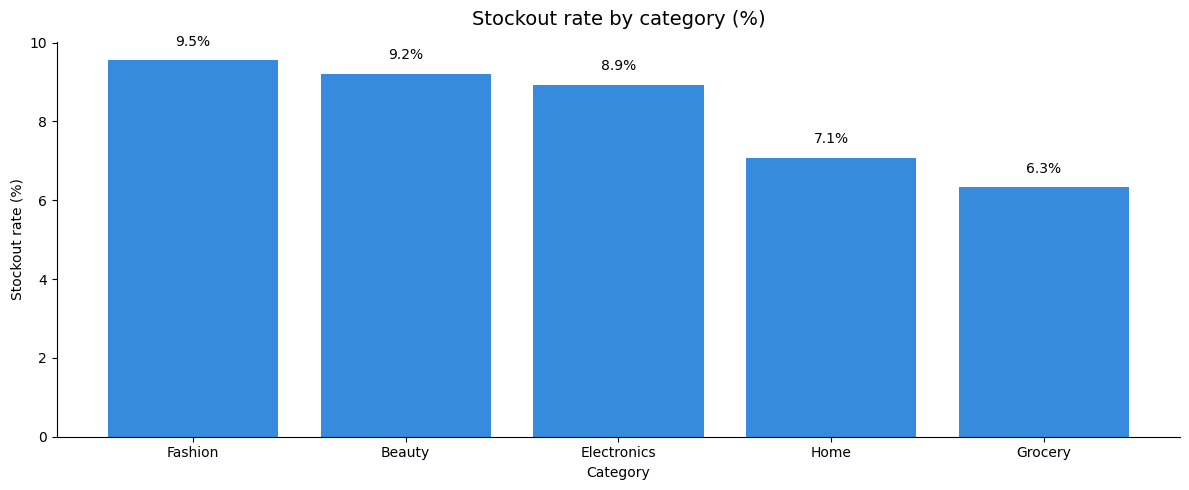

In [4]:
inv_prod = inventory.merge(products[['product_id','category']], on='product_id', how='left')
stockout_rate = inv_prod.groupby('category')['stockout_event'].mean().sort_values(ascending=False)

fig, ax = plt.subplots()
bars = ax.bar(stockout_rate.index, stockout_rate.values * 100, color='#378ADD', edgecolor='none')
ax.set_title('Stockout rate by category (%)', fontsize=14, pad=12)
ax.set_ylabel('Stockout rate (%)')
ax.set_xlabel('Category')
for bar, val in zip(bars, stockout_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val*100:.1f}%', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig(r'C:\Users\chant\ecommerce-analytics\data\processed\chart_stockout_by_category.png', dpi=150)
plt.show()

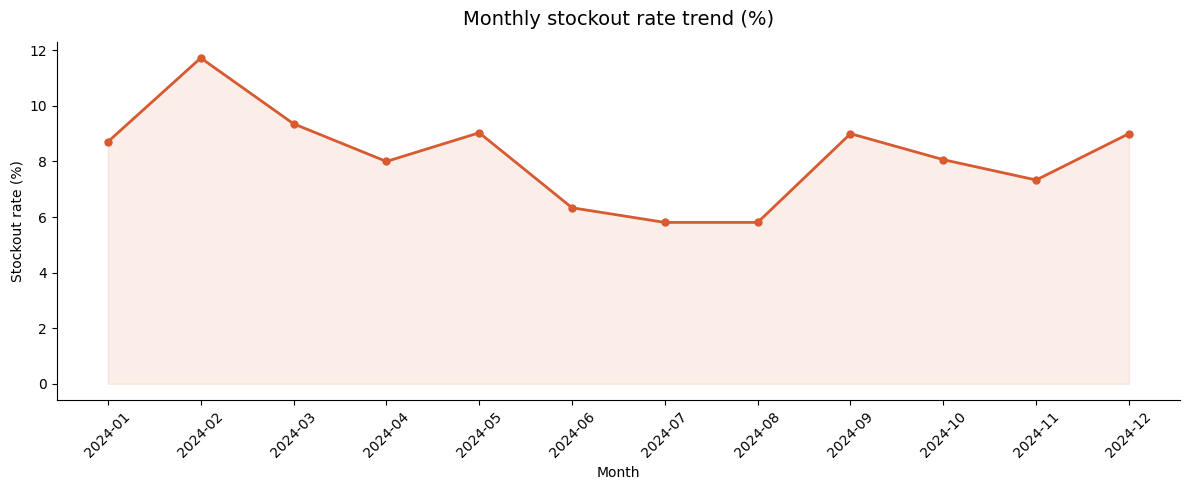

In [5]:
inventory['month'] = inventory['snapshot_date'].dt.to_period('M')
monthly_stockout = inventory.groupby('month')['stockout_event'].mean() * 100

fig, ax = plt.subplots()
ax.plot(monthly_stockout.index.astype(str), monthly_stockout.values,
        marker='o', linewidth=2, color='#D85A30', markersize=5)
ax.fill_between(range(len(monthly_stockout)), monthly_stockout.values, alpha=0.1, color='#D85A30')
ax.set_title('Monthly stockout rate trend (%)', fontsize=14, pad=12)
ax.set_ylabel('Stockout rate (%)')
ax.set_xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(r'C:\Users\chant\ecommerce-analytics\data\processed\chart_stockout_trend.png', dpi=150)
plt.show()

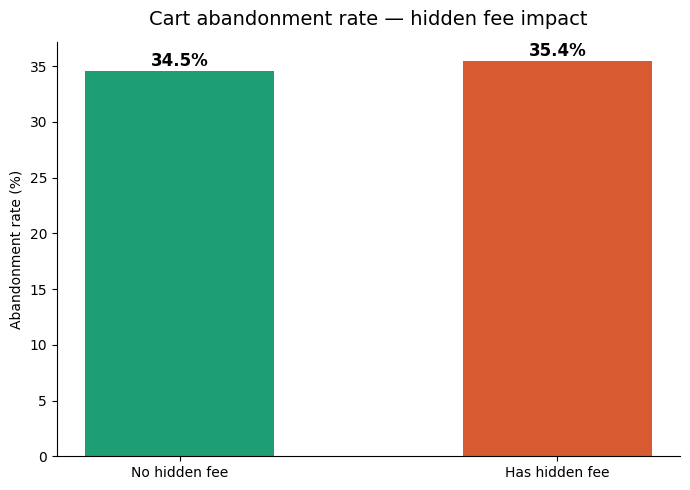

Abandonment with no fee   : 34.5%
Abandonment with hidden fee: 35.4%
Impact: +0.9% increase


In [6]:
orders['has_hidden_fee'] = orders['hidden_fee'] > 0
abandon_rate = orders.groupby('has_hidden_fee')['cart_abandoned'].mean() * 100

fig, ax = plt.subplots(figsize=(7,5))
colors = ['#1D9E75','#D85A30']
bars = ax.bar(['No hidden fee','Has hidden fee'], abandon_rate.values,
               color=colors, width=0.5, edgecolor='none')
ax.set_title('Cart abandonment rate — hidden fee impact', fontsize=14, pad=12)
ax.set_ylabel('Abandonment rate (%)')
for bar, val in zip(bars, abandon_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\chant\ecommerce-analytics\data\processed\chart_hidden_fee_abandonment.png', dpi=150)
plt.show()

print(f"Abandonment with no fee   : {abandon_rate[False]:.1f}%")
print(f"Abandonment with hidden fee: {abandon_rate[True]:.1f}%")
print(f"Impact: +{abandon_rate[True]-abandon_rate[False]:.1f}% increase")

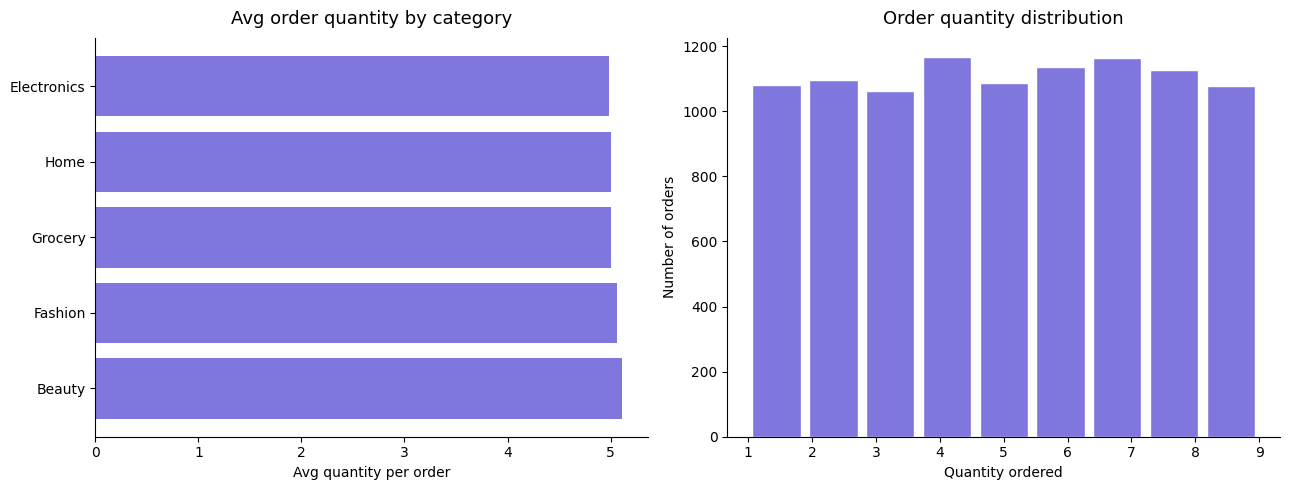

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

orders_prod = orders.merge(products[['product_id','category']], on='product_id', how='left')
qty_by_cat = orders_prod.groupby('category')['quantity'].mean().sort_values(ascending=False)

axes[0].barh(qty_by_cat.index, qty_by_cat.values, color='#7F77DD', edgecolor='none')
axes[0].set_title('Avg order quantity by category', fontsize=13, pad=10)
axes[0].set_xlabel('Avg quantity per order')

axes[1].hist(orders['quantity'], bins=9, color='#7F77DD', edgecolor='white', rwidth=0.85)
axes[1].set_title('Order quantity distribution', fontsize=13, pad=10)
axes[1].set_xlabel('Quantity ordered')
axes[1].set_ylabel('Number of orders')

plt.tight_layout()
plt.savefig(r'C:\Users\chant\ecommerce-analytics\data\processed\chart_bulk_quantity.png', dpi=150)
plt.show()

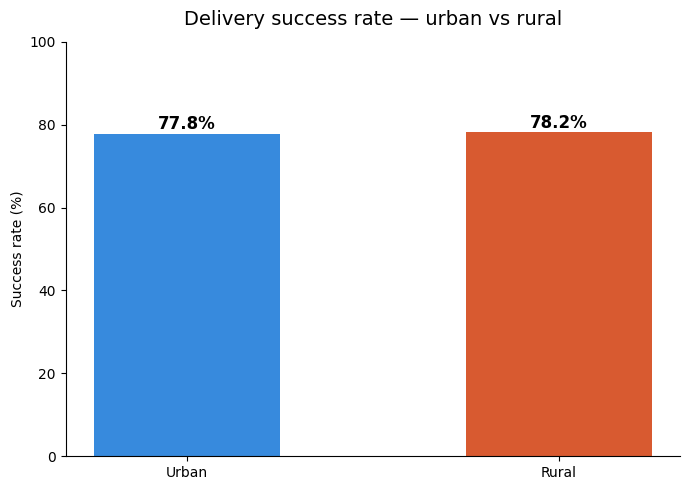

In [9]:
rural_success = deliveries.groupby('is_rural')['delivery_success'].mean() * 100

fig, ax = plt.subplots(figsize=(7,5))
labels = ['Urban','Rural']
colors = ['#378ADD','#D85A30']
bars = ax.bar(labels, rural_success.values, color=colors, width=0.5, edgecolor='none')
ax.set_title('Delivery success rate — urban vs rural', fontsize=14, pad=12)
ax.set_ylabel('Success rate (%)')
ax.set_ylim(0, 100)
for bar, val in zip(bars, rural_success.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\chant\ecommerce-analytics\data\processed\chart_rural_delivery.png', dpi=150)
plt.show()

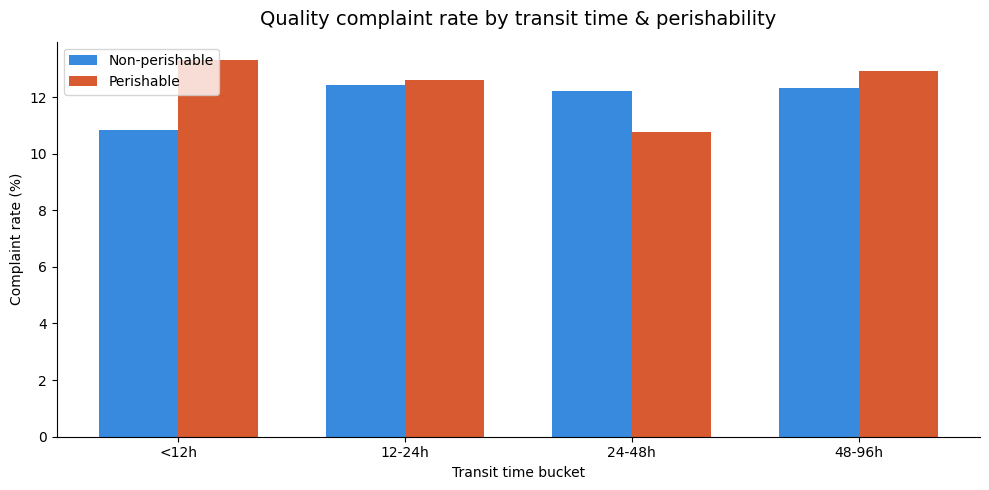

In [10]:
del_prod = deliveries.merge(orders[['order_id','product_id']], on='order_id', how='left')
del_prod = del_prod.merge(products[['product_id','is_perishable']], on='product_id', how='left')

del_prod['transit_bucket'] = pd.cut(del_prod['transit_hours'],
    bins=[0,12,24,48,96], labels=['<12h','12-24h','24-48h','48-96h'])

complaint_rate = del_prod.groupby(['transit_bucket','is_perishable'])['quality_complaint'].mean().unstack() * 100

fig, ax = plt.subplots(figsize=(10,5))
x = np.arange(len(complaint_rate.index))
w = 0.35
ax.bar(x - w/2, complaint_rate[False].values, w, label='Non-perishable', color='#378ADD', edgecolor='none')
ax.bar(x + w/2, complaint_rate[True].values,  w, label='Perishable',     color='#D85A30', edgecolor='none')
ax.set_xticks(x)
ax.set_xticklabels(complaint_rate.index)
ax.set_title('Quality complaint rate by transit time & perishability', fontsize=14, pad=12)
ax.set_ylabel('Complaint rate (%)')
ax.set_xlabel('Transit time bucket')
ax.legend()
plt.tight_layout()
plt.savefig(r'C:\Users\chant\ecommerce-analytics\data\processed\chart_perishable_quality.png', dpi=150)
plt.show()

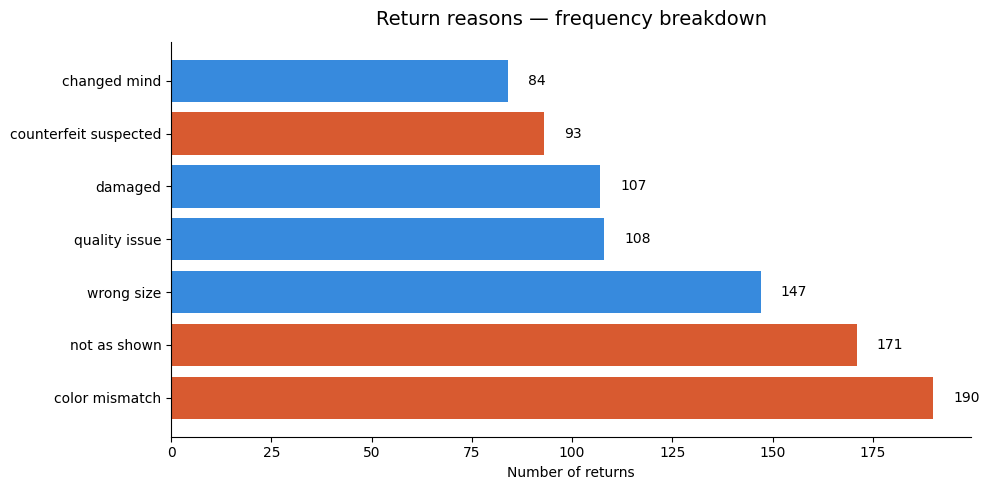

In [11]:
reason_counts = returns['reason'].value_counts()

fig, ax = plt.subplots(figsize=(10,5))
colors_r = ['#D85A30' if 'mismatch' in r or 'shown' in r or 'counterfeit' in r
            else '#378ADD' for r in reason_counts.index]
bars = ax.barh(reason_counts.index, reason_counts.values, color=colors_r, edgecolor='none')
ax.set_title('Return reasons — frequency breakdown', fontsize=14, pad=12)
ax.set_xlabel('Number of returns')
for bar, val in zip(bars, reason_counts.values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10)
plt.tight_layout()
plt.savefig(r'C:\Users\chant\ecommerce-analytics\data\processed\chart_return_reasons.png', dpi=150)
plt.show()

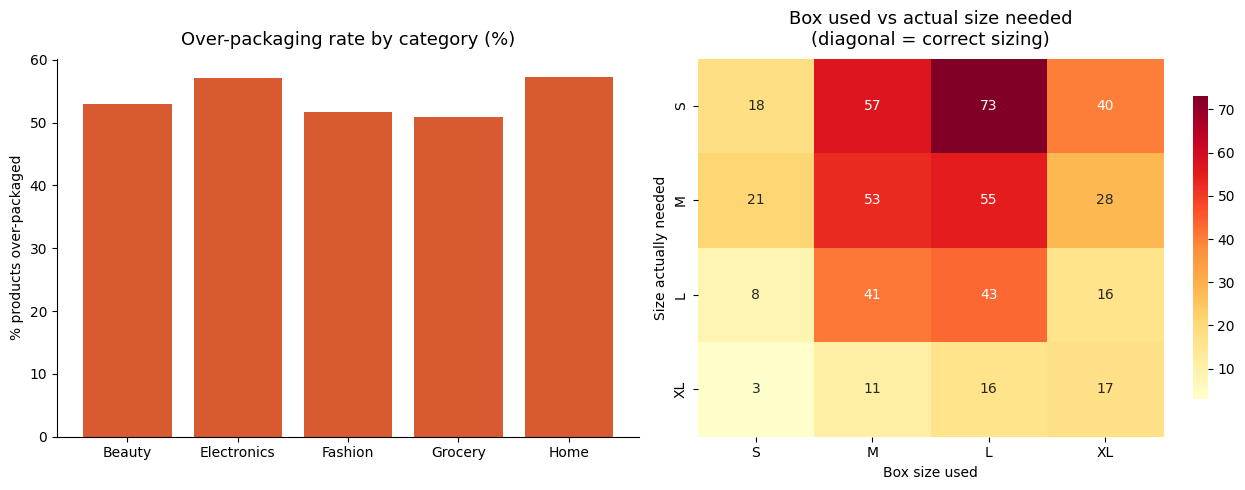

Overall over-packaging rate: 53.8%


In [12]:
size_order = ['S','M','L','XL']
size_map = {'S':1,'M':2,'L':3,'XL':4}
products['box_score'] = products['box_size_used'].map(size_map)
products['needed_score'] = products['actual_size_needed'].map(size_map)
products['overpackaged'] = products['box_score'] > products['needed_score']

fig, axes = plt.subplots(1,2,figsize=(13,5))
waste_by_cat = products.groupby('category')['overpackaged'].mean() * 100
axes[0].bar(waste_by_cat.index, waste_by_cat.values, color='#D85A30', edgecolor='none')
axes[0].set_title('Over-packaging rate by category (%)', fontsize=13, pad=10)
axes[0].set_ylabel('% products over-packaged')

cross = pd.crosstab(products['actual_size_needed'], products['box_size_used'])
cross = cross.reindex(index=size_order, columns=size_order, fill_value=0)
sns.heatmap(cross, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1],
            cbar_kws={'shrink':0.8})
axes[1].set_title('Box used vs actual size needed\n(diagonal = correct sizing)', fontsize=13, pad=10)
axes[1].set_xlabel('Box size used')
axes[1].set_ylabel('Size actually needed')

plt.tight_layout()
plt.savefig(r'C:\Users\chant\ecommerce-analytics\data\processed\chart_packaging_waste.png', dpi=150)
plt.show()
print(f"Overall over-packaging rate: {products['overpackaged'].mean()*100:.1f}%")